# Run BiSSGL

In [3]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [4]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [5]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_bissgl.gz"}

In [6]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

In [7]:
if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [8]:
from sgimc.utils import mc_split

In [9]:
from sgimc.utils import get_submatrix

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sgimc.utils import sparsify_with_mask


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [20]:
import numpy as np


def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten()))))
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[np.int32(
        sorted_predict_score_num*np.arange(1, 1000)/1000)]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]

    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1)-TP
    FN = real_score.sum()-TP
    TN = len(real_score.T)-TP-FP-FN

    fpr = FP/(FP+TN)
    tpr = TP/(TP+FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5*(x_ROC[1:]-x_ROC[:-1]).T*(y_ROC[:-1]+y_ROC[1:])

    recall_list = tpr
    precision_list = TP/(TP+FP)
    PR_dot_matrix = np.mat(sorted(np.column_stack(
        (recall_list, precision_list)).tolist())).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5*(x_PR[1:]-x_PR[:-1]).T*(y_PR[:-1]+y_PR[1:])

    f1_score_list = 2*TP/(len(real_score.T)+TP-TN)
    accuracy_list = (TP+TN)/len(real_score.T)
    specificity_list = TN/(TN+FP)

    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]


In [11]:
random_state = np.random.RandomState(0x0BADCAFE)

In [12]:
from sgimc.utils import load, save

U, V, Y = load(filename_input)

Y = Y.astype(float)

In [13]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

## Load model

In [14]:
import sys

sys.path.append(PATH_ROOT)

from scripts.methods.BiSSGL.BiSSGLc import BiSSGL

## Implementation

In [35]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        # "train_size": np.arange(0.001, 0.2, 0.02),
        "train_size": [0.81],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "tilde_lambda0": [10],
        "tilde_lambda1": [1],
        "lambda0": [10],
        "lambda1": [1],
        "xi": [1],
        "eta": [1e-6],
        "K": [100],
    }
)

# Notes:
# eta is good at 1e-8.

In [29]:
# U = np.eye(Y.shape[0])
# V = np.eye(Y.shape[1])

In [30]:
U, V, _ = load(filename_input)

In [31]:
print(U.shape, V.shape)

(658, 3471) (409, 2217)


In [36]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0

        # set up the model
        xi, eta, tilde_lambda0, tilde_lambda1, lambda0, lambda1, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["tilde_lambda1"],
            par_mdl["lambda0"],
            par_mdl["lambda1"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=tilde_lambda1,
            tilde_alpha=1 / K / 1000,
            tilde_beta=1,
            lambda0=lambda0,
            lambda1=lambda1,
            alpha=1 / K / 1000,
            beta=1,
            K=K,
            max_iter=2500,
            tol=1e-32,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = get_metrics((Y_test.data + 1) / 2, prob_test.data)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "xi": par_mdl["xi"],
                "eta": par_mdl["eta"],
                "tilde_lambda0": par_mdl["tilde_lambda0"],
                "tilde_lambda1": par_mdl["tilde_lambda1"],
                "lambda0": par_mdl["lambda0"],
                "lambda1": par_mdl["lambda1"],
                "K": par_mdl["K"],
                "test_score": scores_test,
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

  0%|          | 0/1 [00:00<?, ?it/s]

Finished with iterations of 2499


100%|██████████| 1/1 [1:31:25<00:00, 5485.71s/it]


In [37]:
results

[{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-06,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 100,
  'test_score': [0.057784432671936295,
   0.740563558556766,
   0.11403508771929824,
   0.9849886671868614,
   0.10612244897959183,
   0.9930628468576571,
   0.12322274881516587],
  'test_d1': 3471,
  'test_d2': 2217}]

In [38]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        # "train_size": np.arange(0.001, 0.2, 0.02),
        "train_size": [0.81],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "tilde_lambda0": [100],
        "tilde_lambda1": [1],
        "lambda0": [100],
        "lambda1": [1],
        "xi": [1],
        "eta": [1e-8],
        "K": [100],
    }
)

# Notes:
# eta is good at 1e-8.

from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0

        # set up the model
        xi, eta, tilde_lambda0, tilde_lambda1, lambda0, lambda1, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["tilde_lambda1"],
            par_mdl["lambda0"],
            par_mdl["lambda1"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=tilde_lambda1,
            tilde_alpha=1 / K / 1000,
            tilde_beta=1,
            lambda0=lambda0,
            lambda1=lambda1,
            alpha=1 / K / 1000,
            beta=1,
            K=K,
            max_iter=2500,
            tol=1e-32,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = get_metrics((Y_test.data + 1) / 2, prob_test.data)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "xi": par_mdl["xi"],
                "eta": par_mdl["eta"],
                "tilde_lambda0": par_mdl["tilde_lambda0"],
                "tilde_lambda1": par_mdl["tilde_lambda1"],
                "lambda0": par_mdl["lambda0"],
                "lambda1": par_mdl["lambda1"],
                "K": par_mdl["K"],
                "test_score": scores_test,
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

results

  0%|          | 0/1 [00:00<?, ?it/s]

Finished with iterations of 2499


100%|██████████| 1/1 [13:28<00:00, 808.72s/it]


[{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 100,
  'test_score': [0.18971482263829748,
   0.796274140374614,
   0.2054794520547945,
   0.9913796306617619,
   0.12244897959183673,
   0.9993625318734063,
   0.6382978723404256],
  'test_d1': 3471,
  'test_d2': 2217}]

{'xi': 1, 'tilde_lambda1': 1, 'tilde_lambda0': 10, 'lambda1': 1, 'lambda0': 10, 'eta': 1e-06, 'K': 100}
0.0025436298669412314


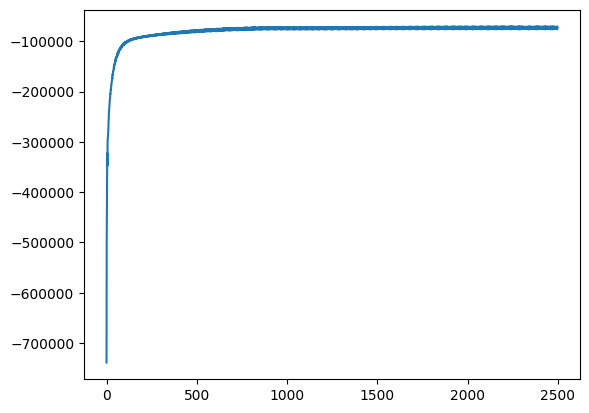

In [26]:
print(grid_model[0])
plt.plot(logLik)
# plt.stem(np.sort(abs(est_A).max(axis=1)))
print(np.min(abs(est_B).max(axis=1)))

noisy

[{'train_size': 0.81,
  'xi': 1,
  'eta': 9.9e-07,
  'tilde_lambda0': 10000,
  'tilde_lambda1': 1,
  'lambda0': 10000,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.8382915548100145,
  'test_d1': 3991,
  'test_d2': 1836}]


In [183]:
filename_output

'/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz'

In [133]:
with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

---

In [60]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0

        # set up the model
        xi, eta, tilde_lambda0, tilde_lambda1, lambda0, lambda1, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["tilde_lambda1"],
            par_mdl["lambda0"],
            par_mdl["lambda1"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=tilde_lambda1,
            tilde_alpha=1 / K,
            tilde_beta=1,
            lambda0=lambda0,
            lambda1=lambda1,
            alpha=1 / K,
            beta=1,
            K=K,
            max_iter=10000,
            tol=1e-8,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(Y_test, prob_test)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # run the k-fold CV
        # splt = ShuffleSplit(**par_dtst, random_state=random_state)
        splt = KFold(par_dtst["n_splits"], shuffle=True, random_state=random_state)
        for cv, (ind_train, ind_valid) in enumerate(splt.split(ind_train_all)):

            # prepare the train and test indices
            ind_train, ind_valid = ind_train_all[ind_train], ind_train_all[ind_valid]
            Y_train = get_submatrix(Y, ind_train)
            Y_valid = get_submatrix(Y, ind_valid)

            Y_train[Y_train == 0] = 0.5
            Y_train[Y_train == -1] = 0

            # fit the model
            model = BiSSGL(
                Y=Y_train.toarray(),
                U=U,
                V=V,
                xi=xi,
                eta=eta,
                tilde_lambda0=tilde_lambda0,
                tilde_lambda1=tilde_lambda1,
                tilde_alpha=1 / K,
                tilde_beta=1,
                lambda0=lambda0,
                lambda1=lambda1,
                alpha=1 / K,
                beta=1,
                K=K,
                max_iter=10000,
                tol=1e-8,
            )

            # fit on the cv dataset
            est_mu, est_A, est_B, logLik = model.optimization()

            # compute the class probabilities
            prob_full = expit(U @ est_A @ est_B.T @ V.T)
            prob_valid = get_submatrix(prob_full, ind_valid)
            scores_valid = mc_get_scores(Y_valid, prob_valid)
            d1_valid = sum(abs(est_A).max(axis=1) > 0)
            d2_valid = sum(abs(est_B).max(axis=1) > 0)

            # record the results
            results.append(
                {
                    "train_size": par_dtst["train_size"],
                    "xi": par_mdl["xi"],
                    "eta": par_mdl["eta"],
                    "tilde_lambda0": par_mdl["tilde_lambda0"],
                    "tilde_lambda1": par_mdl["tilde_lambda1"],
                    "lambda0": par_mdl["lambda0"],
                    "lambda1": par_mdl["lambda1"],
                    "K": par_mdl["K"],
                    "cv": cv,
                    "val_score": scores_valid["auc"],
                    "val_d1": d1_valid,
                    "val_d2": d2_valid,
                    "test_score": scores_test["auc"],
                    "test_d1": d1_test,
                    "test_d2": d2_test,
                }
            )
        # end for
    # end for
# end for

# Save the results in a pickle

with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

  0%|          | 0/1 [00:00<?, ?it/s]

Finished with iterations of 9999


/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Finished with iterations of 9999


/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
100%|██████████| 1/1 [1:53:35<00:00, 6815.72s/it]

Finished with iterations of 9999


In [61]:
filename_output

'/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz'

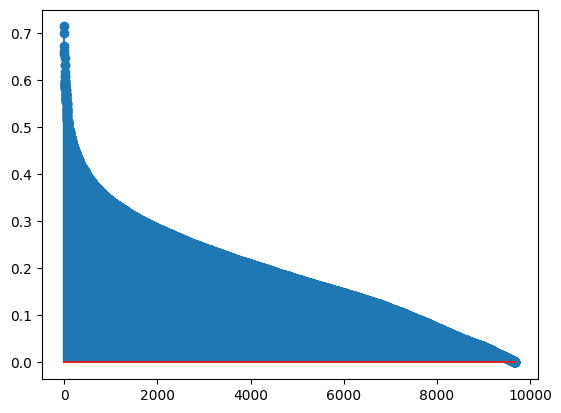

In [62]:
plt.stem(sorted(abs(est_A).max(axis=1), reverse=True))
plt.show()

In [63]:
from collections import defaultdict


def get_final_results(results, param="train_size", hyp_param="C_group"):
    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # averaging the cross-validation results
    results_avg = []

    for ids in id_groups:
        val_res = [id_result[_id] for _id in ids]
        avg_res = np.mean(val_res, axis=0)
        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2, 3]]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    return results_final.T

In [ ]:
PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

for fn in os.listdir(PATH_ARCHIVE):
    filename_results.append(os.path.join(PATH_ARCHIVE, fn))

In [ ]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [68]:
filename_results = "/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz"
results = load(filename_results)

In [69]:
results

[{'train_size': 0.1,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 10,
  'tilde_lambda1': 5,
  'lambda0': 10,
  'lambda1': 5,
  'K': 13,
  'cv': 0,
  'val_score': 0.9118569690649982,
  'val_d1': 9684,
  'val_d2': 33,
  'test_score': 0.9413500218151174,
  'test_d1': 9684,
  'test_d2': 33},
 {'train_size': 0.1,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 10,
  'tilde_lambda1': 5,
  'lambda0': 10,
  'lambda1': 5,
  'K': 13,
  'cv': 1,
  'val_score': 0.9174347217580213,
  'val_d1': 9684,
  'val_d2': 33,
  'test_score': 0.9413500218151174,
  'test_d1': 9684,
  'test_d2': 33}]

In [ ]:
results_final = []
for result in results:
    results_final.append(get_final_results(result, param="train_size", hyp_param="xi"))
results_final = np.array(results_final)
results_bissgl = np.mean(results_final, axis=0)

In [18]:
filename_results = "/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl_merged.json"

In [19]:
import json

with open(filename_results, "rb") as fin:
    results = json.load(fin)

In [112]:
results_final = get_final_results(results, param="xi", hyp_param="xi")
results_final = np.array(results_final)
results_bissgl = results_final

In [114]:
print(results_final, "\n", results_bissgl)

[[10.          1.          2.          5.          3.        ]
 [ 0.6784461   0.65194554  0.66613224  0.67710896  0.66750391]] 
 [[10.          1.          2.          5.          3.        ]
 [ 0.6784461   0.65194554  0.66613224  0.67710896  0.66750391]]


In [119]:
import matplotlib.lines as mlines

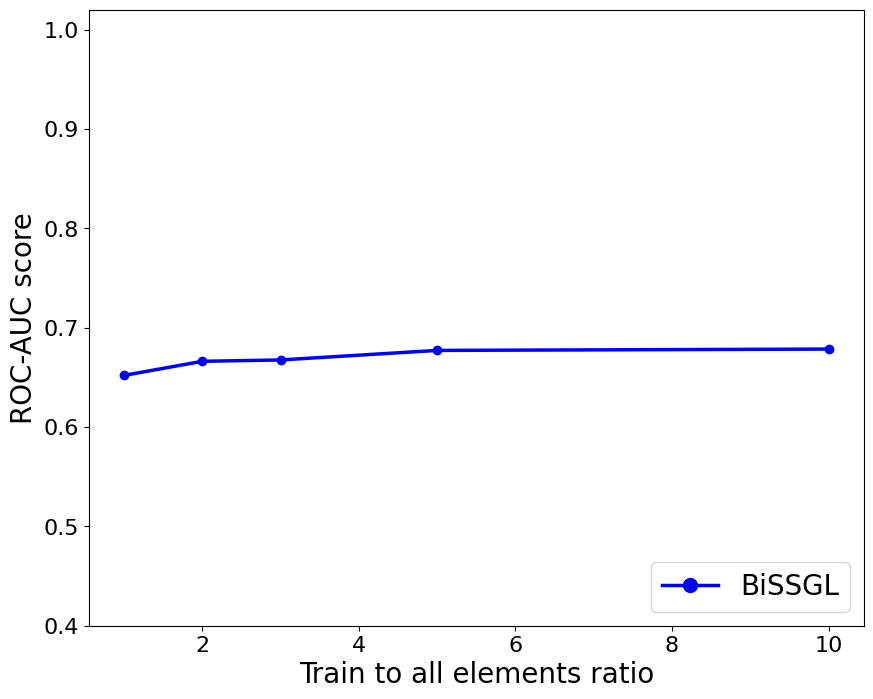

In [120]:
plt.figure(figsize=(10, 8))

# lines
bissgl_line = mlines.Line2D(
    [], [], color="blue", marker="o", linewidth=2.5, markersize=10, label="BiSSGL"
)
# imc_line = mlines.Line2D([], [], color='red', marker='s', linewidth=2.5,
#                          markersize=10, label='IMC')
# mf_line = mlines.Line2D([], [], color='green', marker='^', linewidth=2.5,
#                         markersize=10, label='MF')
# sgimc_comb_line = mlines.Line2D([], [], color='blue', marker='o', linewidth=2.5, linestyle='--',
#                                 markersize=10, label='SGIMC-comb')
# imc_comb_line = mlines.Line2D([], [], color='red', marker='s', linewidth=2.5, linestyle='--',
#                               markersize=10, label='IMC-comb')

# curves
plt.plot(results_bissgl[0], results_bissgl[1], "b-", label="BiSSGL", linewidth=2.5)
# plt.plot(results_imc[0], results_imc[1], 'r-', label='IMC', linewidth=2.5)
# plt.plot(results_mf[0], results_mf[1], 'g-', label='MF', linewidth=2.5)
# plt.plot(results_bissgl_comb[0], results_bissgl_comb[1], 'b--', label='SGIMC-comb', linewidth=2.5)
# plt.plot(results_imc_comb[0], results_imc_comb[1], 'r--', label='IMC-comb', linewidth=2.5)

# dotes
plt.plot(results_bissgl[0], results_bissgl[1], "bo", label="BiSSGL", linewidth=2.5)
# plt.plot(results_imc[0], results_imc[1], 'rs', label='IMC', linewidth=2.5)
# plt.plot(results_mf[0], results_mf[1], 'g^', label='MF', linewidth=2.5)
# plt.plot(results_bissgl_comb[0], results_bissgl_comb[1], 'bo', label='SGIMC-comb', linewidth=2.5)
# plt.plot(results_imc_comb[0], results_imc_comb[1], 'rs', label='IMC-comb', linewidth=2.5)

# specify axis limits and labels
plt.ylim((0.4, 1.02))
plt.xlabel("Train to all elements ratio", fontsize=20)
plt.ylabel("ROC-AUC score", fontsize=20)

# ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# legend
plt.legend(
    handles=[
        bissgl_line,  # imc_line, mf_line, sgimc_comb_line, imc_comb_line
    ],
    fontsize=20,
    loc=4,
)

plt.show()

---

## Confidence levels

### The noisy case

In [28]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": [0.2],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "tilde_lambda0": [12],
        "tilde_lambda1": [3],
        "lambda0": [5],
        "lambda1": [3],
        # "xi": [1, 1.2, 1.5, 2, 5, 10],
        "xi": [10],
        "eta": [1e-9],
        "K": [13],
    }
)

# Notes:
# eta cannot be as large as 5e-7.
# eta is good at 2e-7.
# tilde_lambda0, tilde_lambda1, lambda0, lambda1 cannot do the selection well.

In [29]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        # Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0

        # set up the model
        xi, eta, tilde_lambda0, tilde_lambda1, lambda0, lambda1, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["tilde_lambda1"],
            par_mdl["lambda0"],
            par_mdl["lambda1"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=tilde_lambda1,
            tilde_alpha=1 / 10000,
            tilde_beta=10,
            lambda0=lambda0,
            lambda1=lambda1,
            alpha=1 / 100,
            beta=10,
            K=K,
            max_iter=2000,
            tol=1e-8,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(Y_test, prob_test)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "xi": par_mdl["xi"],
                "eta": par_mdl["eta"],
                "tilde_lambda0": par_mdl["tilde_lambda0"],
                "tilde_lambda1": par_mdl["tilde_lambda1"],
                "lambda0": par_mdl["lambda0"],
                "lambda1": par_mdl["lambda1"],
                "K": par_mdl["K"],
                "test_score": scores_test["auc"],
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [09:01<00:00, 541.85s/it]

Finished with iterations of 1999


0.23420714998501535


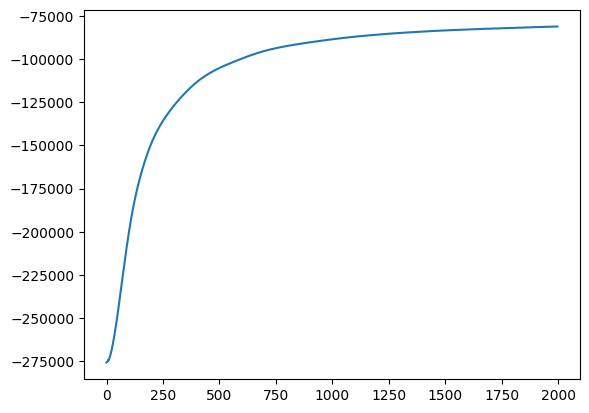

In [30]:
plt.plot(logLik)
# plt.stem(np.sort(abs(est_A).max(axis=1)))
print(np.min(abs(est_B).max(axis=1)))

In [31]:
results

[{'train_size': 0.2,
  'xi': 10,
  'eta': 1e-09,
  'tilde_lambda0': 12,
  'tilde_lambda1': 3,
  'lambda0': 5,
  'lambda1': 3,
  'K': 13,
  'test_score': 0.9118457370264484,
  'test_d1': 9684,
  'test_d2': 33}]

In [ ]:
[{'train_size': 0.81,
  'xi': 10,
  'eta': 5e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.7237009578092523,
  'test_d1': 4020,
  'test_d2': 1860},
 {'train_size': 0.81,
  'xi': 10,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.6937797497880207,
  'test_d1': 4020,
  'test_d2': 1860}]
  [{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': 0.7996277737133552,
  'test_d1': 4020,
  'test_d2': 1860}]
  [{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-07,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': 0.6149213457694462,
  'test_d1': 4020,
  'test_d2': 1860}]
  [{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.7928856108214996,
  'test_d1': 4020,
  'test_d2': 1860}]
  [{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-07,
  'tilde_lambda0': 1000,
  'tilde_lambda1': 1,
  'lambda0': 1000,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.7312079293994483,
  'test_d1': 4020,
  'test_d2': 1860}]
  [{'train_size': 0.81,
  'xi': 1,
  'eta': 5e-07,
  'tilde_lambda0': 1000,
  'tilde_lambda1': 1,
  'lambda0': 1000,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.6694096417628097,
  'test_d1': 4020,
  'test_d2': 1860}]
  [{'train_size': 0.81,
  'xi': 1,
  'eta': 8e-07,
  'tilde_lambda0': 1000,
  'tilde_lambda1': 1,
  'lambda0': 1000,
  'lambda1': 1,
  'K': 50,
  'test_score': 0.7024906407740837,
  'test_d1': 4003,
  'test_d2': 1857}]